# KANVAS, Phase 4: An Honest Benchmark, and a Test of the Interpretability Claim

Phases 2 and 3 built KANVAS on 2,310 tasks from Alibaba's PAI GPU cluster and made its curves trustworthy. This notebook answers the two questions a reviewer will ask first:

1. **What does interpretability cost?** On the same test tasks, how does KAAM compare with the simplest interpretable model and with a black-box network of the same size?
2. **Is the built-in explanation real?** KAAM's curves are its explanation by construction. Do they agree with an independent, post-hoc explanation of a model that was never built to be interpretable?

## Three models, three kinds of explanation

| | What the model is | How it explains a prediction |
|---|---|---|
| **Logistic regression** | $\text{logit} = b + \sum_i w_i x_i$. **Additive and interpretable, but every $\varphi_i$ is forced to be a straight line**, $\varphi_i(x) = w_i x$. | Its coefficients *are* the explanation, but only if every effect really is linear. A U-shape, a threshold or a plateau gets flattened into a single slope. |
| **KAAM** | $\text{logit} = b + \sum_i \varphi_i(x_i)$. **Additive and interpretable, with no such assumption**: each $\varphi_i$ can take any smooth shape the data supports. | Its curves *are* the explanation, exactly. Every prediction is the sum of ten readable contributions, with nothing approximated. |
| **MLP** | Layers of ReLU units that mix every feature with every other. **Neither additive nor interpretable on its own.** | There is no built-in explanation. To explain it at all we need a post-hoc tool (SHAP here) that *estimates* each feature's contribution after the fact. |

**That table is the paper's core argument.**
- Logistic regression buys interpretability by assuming linearity.
- The MLP buys flexibility by giving up interpretability.
- KAAM claims to keep both: additive and exact like logistic regression, but with curves free to bend.

This notebook tests both halves of that claim:
- the **accuracy half** with a capacity-matched benchmark (sections 2–5), where the honest expectation is that the unconstrained MLP may simply score higher;
- the **interpretability half** by checking whether KAAM's intrinsic feature importance agrees with SHAP's post-hoc importance for the MLP (section 6).

### Protocol (same as Phase 3)
- Same 2,310 tasks and the same stratified 70/15/15 split (`random_state=42`).
- Same [0, 1] min-max scaling for every model, fitted on the training split only.
- Every hyperparameter is chosen on **validation** data: LR's C, the MLP's architecture and learning rate. KAAM's λ = 0.001 was fixed in Phase 3.
- The test split is scored once, in section 5.

In [1]:
import sys
import time
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from cycler import cycler

from kanvas.baselines import (MLP, MLP_HIDDEN_CANDIDATES, benchmark, count_parameters, kaam_parameter_breakdown,
                              lr_predict_proba, paired_auc_differences, score_test_set, tune_logistic_regression,
                              tune_mlp)
from kanvas.data import FEATURE_NAMES, scale_features
from kanvas.model import KAAM
from kanvas.shap_analysis import (agreement_extremes, compare_rankings, kaam_curve_range_importance, kaam_logit,
                                  kaam_shap_values, kernel_shap_values, mlp_logit, mlp_shap_values,
                                  plot_dependence_pairs, plot_importance_comparison, shap_importance)
from kanvas.training import (classification_metrics, predict_proba, smoothness_penalty, train_kaam,
                             train_val_test_split, tune_threshold)
from kanvas.utils import set_seed

%matplotlib inline
pd.set_option("display.width", 220)

# Chart style (same as Phases 2-3): light surface, hairline grid, ink-toned text.
SURFACE, INK, INK_2, BASELINE = "#fcfcfb", "#0b0b0b", "#52514e", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": BASELINE, "ytick.color": BASELINE, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.prop_cycle": cycler(color=["#2a78d6", "#eb6834"]), "lines.linewidth": 1.5,
    "legend.frameon": False, "font.size": 10,
})

## 1. Data and split

This is Phase 2's exact feature matrix, loaded from disk rather than rebuilt, split exactly as in Phase 3.

In [2]:
df = pd.read_csv("../data/processed/kanvas_features.csv", index_col=["job_name", "task_name"])
X, y = df[FEATURE_NAMES], df["label"]
assert X.shape == (2310, 10) and int(y.sum()) == 646

X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X, y, val_size=0.15, test_size=0.15, random_state=42)
for name, part in (("train", y_train), ("validation", y_val), ("test", y_test)):
    print(f"{name:<11s} {len(part):>5,} tasks  failure rate {part.mean():.2%}")

train       1,616 tasks  failure rate 27.97%
validation    347 tasks  failure rate 27.95%
test          347 tasks  failure rate 27.95%


## 2. Reproduce the Phase 3 KAAM

Phase 3 didn't save a checkpoint, so KAAM is retrained with the exact Phase 3 recipe: λ = 0.001, `set_seed(42)`, 10 knots, cubic splines, Adam at lr = 0.01, patience 15, a 500-epoch cap. Training is deterministic, so the run must land on Phase 3's validation fingerprints exactly (asserted below). Its test AUC is checked against Phase 3's 0.7169 in section 5.

One thing did change underneath: `train_kaam` is now a thin wrapper around a model-agnostic `train_early_stopping`, which the MLP below reuses. Before this notebook was written, the refactored loop was verified to be **bit-identical** to Phase 3's: the same validation and test predictions, and the same per-epoch validation loss, compared with `np.array_equal`.

In [3]:
UNIT_RANGES = {name: (0.0, 1.0) for name in FEATURE_NAMES}
set_seed(42)
kaam = KAAM(FEATURE_NAMES, UNIT_RANGES, num_knots=10, spline_order=3)
start = time.perf_counter()
kaam_result = train_kaam(kaam, X_train, y_train, X_val, y_val, lambda_smooth=0.001, patience=15, max_epochs=500)
kaam_seconds = time.perf_counter() - start

print(f"\nPhase 3 fingerprints: restored epoch {kaam_result.best_epoch} (expected 167), "
      f"val BCE {kaam_result.best_val_loss:.4f} (expected 0.4868), roughness {smoothness_penalty(kaam).item():.4f} (expected 5.3566)")
assert kaam_result.best_epoch == 167 and round(kaam_result.best_val_loss, 4) == 0.4868

Epoch   20  train loss 0.5439 (BCE 0.5407 + lambda*penalty 0.0032)  val loss 0.5372


Epoch   40  train loss 0.5110 (BCE 0.5071 + lambda*penalty 0.0039)  val loss 0.5081


Epoch   60  train loss 0.4977 (BCE 0.4927 + lambda*penalty 0.0050)  val loss 0.4978


Epoch   80  train loss 0.4893 (BCE 0.4838 + lambda*penalty 0.0055)  val loss 0.4925


Epoch  100  train loss 0.4835 (BCE 0.4779 + lambda*penalty 0.0057)  val loss 0.4896


Epoch  120  train loss 0.4794 (BCE 0.4738 + lambda*penalty 0.0056)  val loss 0.4879


Epoch  140  train loss 0.4765 (BCE 0.4710 + lambda*penalty 0.0055)  val loss 0.4871


Epoch  160  train loss 0.4745 (BCE 0.4691 + lambda*penalty 0.0054)  val loss 0.4868


Epoch  180  train loss 0.4730 (BCE 0.4677 + lambda*penalty 0.0053)  val loss 0.4868
Early stopping triggered at epoch 182: val loss has not improved for 15 epochs. Restored weights from epoch 167 (val loss 0.4868).

Phase 3 fingerprints: restored epoch 167 (expected 167), val BCE 0.4868 (expected 0.4868), roughness 5.3566 (expected 5.3566)


## 3. Baseline 1: logistic regression

The simplest interpretable model: $\text{logit} = b + \sum_i w_i x_i$ on the same ten [0, 1]-scaled features, with an L2 penalty whose strength $1/C$ is chosen by **validation AUC** over eleven values of C from 0.001 to 100.

Because every input is scaled to [0, 1] over its training range, each coefficient $w_i$ reads directly as **the change in failure log-odds as that feature moves from its training minimum to its training maximum**. That is logistic regression's version of a $\varphi_i$ curve: a straight line with slope $w_i$.

In [4]:
lr_model, lr_ranges, lr_seconds, lr_table = tune_logistic_regression(X_train, y_train, X_val, y_val)
print(lr_table.round(4).to_string(index=False))
lr_params = lr_model.coef_.size + lr_model.intercept_.size
print(f"\nchosen C = {lr_model.C} (validation AUC {lr_table['val AUC'].max():.4f}); {lr_params} parameters")

lr_coefs = pd.Series(lr_model.coef_[0], index=FEATURE_NAMES, name="coefficient")
print("\nLR coefficients: change in failure log-odds from each feature's training min to its max")
print(lr_coefs.to_frame().assign(rank=lr_coefs.abs().rank(ascending=False).astype(int))
      .sort_values("rank").round(3).to_string())
print(f"intercept {lr_model.intercept_[0]:+.3f}")

      C  val AUC
  0.001   0.7230
  0.003   0.7281
  0.010   0.7373
  0.030   0.7428
  0.100   0.7429
  0.300   0.7344
  1.000   0.7287
  3.000   0.7297
 10.000   0.7288
 30.000   0.7284
100.000   0.7281

chosen C = 0.1 (validation AUC 0.7429); 11 parameters

LR coefficients: change in failure log-odds from each feature's training min to its max
                 coefficient  rank
plan_cpu              -1.502     1
plan_mem               0.911     2
cap_gpu                0.810     3
plan_gpu              -0.587     4
inst_num              -0.298     5
avg_cpu_kernel         0.265     6
avg_load_1            -0.234     7
avg_net_receive       -0.039     8
avg_cpu_usr            0.035     9
avg_gpu_util          -0.003    10
intercept -1.383


**Reading the logistic regression.**
- **Validation AUC peaks at C = 0.1 (0.743)**, a fairly strong L2 penalty, and falls off on both sides.
- **The coefficients are logistic regression's whole explanation**, one slope per feature:
  - requesting more CPU lowers the risk steeply (−1.50 log-odds across the training range);
  - more memory raises it (+0.91), and so does landing on an 8-GPU node (+0.81, since `cap_gpu` only takes the values 2 and 8);
  - more GPU requested lowers it (−0.59).
- **Three of the five node-telemetry features get almost exactly zero** (|w| ≤ 0.04): user CPU, GPU utilization and network receive. Kernel CPU (+0.27) and load (−0.23) are small. A straight line can only say "more is worse" or "more is better". If an effect bends, or if its information is already carried by a correlated feature like `cap_gpu`, the best straight line is nearly flat.
- **A practical consequence:** the strong penalty pulls every predicted probability toward the 28% base rate. On validation, LR's highest predicted probability is 0.478, so at the conventional 0.5 threshold it flags no task at all. That matters in section 5.

## 4. Baseline 2: an MLP with the same capacity as KAAM

A fair black-box baseline needs roughly the same number of learnable parameters; otherwise any accuracy gap could just be a capacity gap. So we first count KAAM's parameters exactly, then only consider MLPs within ±20% of that count.

In [5]:
kaam_params = count_parameters(kaam)
print("KAAM learnable parameters:", kaam_parameter_breakdown(kaam))
print("  each of the 10 edges: 14 spline coefficients + 1 SiLU base weight. BSplineEdge has no per-edge bias,")
print("  and its knot grid is a fixed buffer, not a parameter. Plus one global bias.")

low, high = 0.8 * kaam_params, 1.2 * kaam_params
candidates = pd.DataFrame([{"hidden layers": h, "parameters": count_parameters(MLP(len(FEATURE_NAMES), h))}
                           for h in MLP_HIDDEN_CANDIDATES])
candidates["vs KAAM"] = (candidates["parameters"] / kaam_params - 1).map("{:+.1%}".format)
print(f"\nMLP candidates (10 inputs, ReLU hidden layers, 1 sigmoid output); capacity band {low:.1f}–{high:.1f}:")
print(candidates.to_string(index=False))
assert candidates["parameters"].between(low, high).all()

KAAM learnable parameters: {'spline coefficients': 140, 'base weights': 10, 'global bias': 1, 'total': 151}
  each of the 10 edges: 14 spline coefficients + 1 SiLU base weight. BSplineEdge has no per-edge bias,
  and its knot grid is a fixed buffer, not a parameter. Plus one global bias.

MLP candidates (10 inputs, ReLU hidden layers, 1 sigmoid output); capacity band 120.8–181.2:
hidden layers  parameters vs KAAM
        (12,)         145   -4.0%
        (14,)         169  +11.9%
       (8, 6)         149   -1.3%
       (8, 8)         169  +11.9%


Each candidate architecture is trained at three learning rates (0.003, 0.01, 0.03) with **the same `train_early_stopping` loop KAAM uses**:
- full-batch Adam;
- patience 15 on validation BCE, and a 500-epoch cap;
- the best-validation weights restored at the end.

The configuration with the best **validation AUC** is kept, the same criterion used for C in logistic regression.

In [6]:
mlp, mlp_result, mlp_seconds, mlp_table = tune_mlp(X_train, y_train, X_val, y_val)
print(mlp_table.round(4).to_string(index=False))

mlp_params = count_parameters(mlp)
chosen = mlp_table.loc[mlp_table["val AUC"].idxmax()]
print(f"\nchosen MLP: hidden layers {chosen['hidden']}, lr {chosen['lr']}; restored epoch {mlp_result.best_epoch} "
      f"(early-stopped at {mlp_result.stopped_epoch}); validation AUC {chosen['val AUC']:.4f}")
print(f"PARAMETER-COUNT FAIRNESS CHECK: KAAM {kaam_params}  vs  MLP {mlp_params}  "
      f"({mlp_params / kaam_params - 1:+.1%}; within 20%: {abs(mlp_params - kaam_params) <= 0.2 * kaam_params})")

hidden    lr  parameters  best epoch  stopped at  val BCE  val AUC
 (12,) 0.003         145         500         500   0.4908   0.7675
 (12,) 0.010         145         192         207   0.5018   0.7578
 (12,) 0.030         145          88         103   0.5012   0.7579
 (14,) 0.003         169         500         500   0.4892   0.7499
 (14,) 0.010         169         279         294   0.5026   0.7576
 (14,) 0.030         169         149         164   0.4719   0.7756
(8, 6) 0.003         149         419         434   0.4795   0.7614
(8, 6) 0.010         149         390         405   0.4615   0.7948
(8, 6) 0.030         149         176         191   0.4729   0.7960
(8, 8) 0.003         169         290         305   0.4715   0.7776
(8, 8) 0.010         169         182         197   0.4677   0.7945
(8, 8) 0.030         169         108         123   0.5091   0.7423

chosen MLP: hidden layers (8, 6), lr 0.03; restored epoch 176 (early-stopped at 191); validation AUC 0.7960
PARAMETER-COUNT FAIR

**Reading the MLP sweep (validation only).**
- **Selected: two hidden layers (8, 6) at lr = 0.03.** It has 149 parameters, 1.3% fewer than KAAM's 151, and is restored from epoch 176 after early stopping at 191. Its validation AUC is **0.796**, against 0.761 for KAAM and 0.743 for logistic regression.
- **The result doesn't hinge on one lucky configuration.** The runners-up sit right behind: (8, 6) at lr = 0.01 scores 0.7948, and (8, 8) at lr = 0.01 scores 0.7945. Two-layer networks beat one-layer ones throughout.
- **Two slow configurations were cut off.** (12,) and (14,) at lr = 0.003 were still improving at the same 500-epoch cap KAAM uses. They are under-trained rather than converged, though even the better of them trailed the selected network on validation.
- **0.796 is optimistic.** It is the best of 12 noisy validation estimates. The test set in section 5 is the honest check, and the same caveat applies to LR's C (best of 11) and KAAM's λ (best of 4).

## 5. The benchmark: one evaluation on the test set

Every choice is now frozen: KAAM's λ from Phase 3, LR's C and the MLP's configuration from validation.

The cell below is the only one that scores models on `X_test`:
- It scores all three models **on the one `X_test` DataFrame** and asserts that their prediction indices are identical arrays: the same tasks, in the same order.
- Accuracy, precision, recall and F1 use the default 0.5 threshold for every model. (Phase 3 showed that validation-tuned thresholds didn't help.)
- AUC and the **Brier score** (mean squared error of the predicted probability, lower is better) don't depend on a threshold.
- AUC comes with a 95% bootstrap interval. Each pairwise AUC difference comes with a **paired** bootstrap interval: the same 2,000 resamples of test tasks, seed 0, exactly as in Phase 3's λ comparison.
- A **supplementary** table re-scores the threshold metrics at each model's own validation-tuned threshold (max F1 on validation, as in Phase 3). A single 0.5 cut-off can be a poor fit for a model whose probabilities are compressed. The primary table stays at 0.5.

In [7]:
# Validation only: each model's own max-F1 threshold, used by the supplementary table in the test cell.
val_scores = {
    "KAAM": predict_proba(kaam, X_val, kaam_result.feature_ranges),
    "LR": lr_predict_proba(lr_model, X_val, lr_ranges),
    "MLP": predict_proba(mlp, X_val, mlp_result.feature_ranges),
}
tuned_thresholds = {}
for name, p_val in val_scores.items():
    tuned_thresholds[name], _ = tune_threshold(y_val, p_val)
    print(f"{name:<5s} highest validation probability {p_val.max():.3f};  validation max-F1 threshold {tuned_thresholds[name]:.2f}")

KAAM  highest validation probability 0.737;  validation max-F1 threshold 0.60


LR    highest validation probability 0.478;  validation max-F1 threshold 0.40


MLP   highest validation probability 0.611;  validation max-F1 threshold 0.25


In [8]:
# ---- the single test-set evaluation ----
predictions = score_test_set({
    "KAAM": lambda X: predict_proba(kaam, X, kaam_result.feature_ranges),
    "LR": lambda X: lr_predict_proba(lr_model, X, lr_ranges),
    "MLP": lambda X: predict_proba(mlp, X, mlp_result.feature_ranges),
}, X_test)
index_arrays = [p.index.to_numpy() for p in predictions.values()]
assert all(np.array_equal(a, index_arrays[0]) for a in index_arrays), "models were scored on different test rows"

results = benchmark(y_test, predictions,
                    parameters={"KAAM": kaam_params, "LR": lr_params, "MLP": mlp_params},
                    train_seconds={"KAAM": kaam_seconds, "LR": lr_seconds, "MLP": mlp_seconds})
assert abs(results.loc["KAAM", "AUC"] - 0.7169) < 5e-4, "KAAM does not reproduce the Phase 3 test AUC"

fmt = {c: "{:.4f}".format for c in ["accuracy", "AUC", "precision", "recall", "F1", "Brier"]}
fmt.update({"parameters": "{:.0f}".format, "train seconds": "{:.2f}".format})
print(f"Test set: {len(y_test)} tasks, {int(y_test.sum())} failures; threshold 0.5\n")
print(results.to_string(formatters=fmt))
base_rate = y_train.mean()
print(f"\nreference points: always predicting Terminated scores accuracy {1 - y_test.mean():.4f}; "
      f"predicting the {base_rate:.1%} training failure rate for every task scores Brier {((y_test - base_rate) ** 2).mean():.4f}")

diffs = paired_auc_differences(y_test, predictions, [("KAAM", "LR"), ("KAAM", "MLP"), ("MLP", "LR")])
print("\nPaired AUC differences (same 2,000 bootstrap resamples of test tasks, seed 0):")
print(diffs.to_string(formatters={c: "{:+.4f}".format for c in ["AUC difference", "95% CI low", "95% CI high"]}))

tuned_rows = {}
for name, p in predictions.items():
    m = classification_metrics(y_test.to_numpy(), p.to_numpy(), tuned_thresholds[name])
    tuned_rows[name] = {"threshold (val max-F1)": f"{tuned_thresholds[name]:.2f}", "accuracy": f"{m['accuracy']:.4f}",
                        "precision": f"{m['precision']:.4f}", "recall": f"{m['recall']:.4f}", "F1": f"{m['f1']:.4f}",
                        "failures caught": f"{m['tp']}/{m['tp'] + m['fn']}", "false alarms": m["fp"]}
print("\nSupplementary: threshold metrics at each model's validation-tuned threshold")
print(pd.DataFrame(tuned_rows).T.to_string())

Test set: 347 tasks, 97 failures; threshold 0.5

     accuracy     AUC      AUC 95% CI precision  recall      F1   Brier parameters train seconds
KAAM   0.7867  0.7169  [0.652, 0.776]    0.7091  0.4021  0.5132  0.1652        151         13.15
LR     0.7205  0.7052  [0.642, 0.764]       NaN  0.0000  0.0000  0.1790         11          0.01
MLP    0.8040  0.7299  [0.668, 0.788]    0.7843  0.4124  0.5405  0.1633        149          0.44

reference points: always predicting Terminated scores accuracy 0.7205; predicting the 28.0% training failure rate for every task scores Brier 0.2014



Paired AUC differences (same 2,000 bootstrap resamples of test tasks, seed 0):
           AUC difference 95% CI low 95% CI high  CI includes 0
comparison                                                     
KAAM - LR         +0.0117    -0.0278     +0.0521           True
KAAM - MLP        -0.0130    -0.0609     +0.0327           True
MLP - LR          +0.0247    -0.0276     +0.0780           True

Supplementary: threshold metrics at each model's validation-tuned threshold
     threshold (val max-F1) accuracy precision  recall      F1 failures caught false alarms
KAAM                   0.60   0.7896    0.7400  0.3814  0.5034           37/97           13
LR                     0.40   0.7983    0.7647  0.4021  0.5270           39/97           12
MLP                    0.25   0.7406    0.5376  0.5155  0.5263           50/97           43


In [9]:
# Built-in interpretability, side by side: model properties only, no test data.
p5, p95 = X_train.quantile(0.05), X_train.quantile(0.95)
window = pd.Series({n: (p95[n] - p5[n]) / (lr_ranges[n][1] - lr_ranges[n][0]) for n in FEATURE_NAMES})
kaam_range = kaam_curve_range_importance(kaam, X_train, kaam_result.feature_ranges)
print("\nBuilt-in interpretability, side by side (log-odds; no test data involved):")
print(pd.DataFrame({
    "LR coefficient (min->max)": lr_coefs,
    "LR |effect| over p5-p95": lr_coefs.abs() * window,
    "KAAM phi range over p5-p95": kaam_range,
}).round(3).to_string())


Built-in interpretability, side by side (log-odds; no test data involved):
                 LR coefficient (min->max)  LR |effect| over p5-p95  KAAM phi range over p5-p95
plan_cpu                            -1.502                    1.435                       1.798
plan_mem                             0.911                    0.825                       0.790
plan_gpu                            -0.587                    0.271                       0.485
inst_num                            -0.298                    0.116                       0.425
avg_cpu_usr                          0.035                    0.023                       0.291
avg_gpu_util                        -0.003                    0.002                       0.228
avg_cpu_kernel                       0.265                    0.165                       0.723
avg_load_1                          -0.234                    0.099                       0.428
cap_gpu                              0.810                  

**Reading the benchmark.**

**Ranking (AUC).** The capacity-matched MLP scores highest, 0.730, then KAAM at 0.717 and LR at 0.705. That order is the expected one: the MLP can model interactions, KAAM only per-feature curves, LR only straight lines. **But all three paired intervals include zero:**
- KAAM − LR: +0.012 [−0.028, +0.052];
- KAAM − MLP: −0.013 [−0.061, +0.033];
- MLP − LR: +0.025 [−0.028, +0.078].

On 347 test tasks with 97 failures, none of the three models is distinguishable from the others on ranking. KAAM costs about 0.013 AUC against a same-size black box, and gains about 0.012 over logistic regression; this test set can't tell either difference from zero.

The validation-to-test drop is also worth noting: 0.066 AUC for the MLP (best of 12 validation candidates), 0.044 for KAAM and 0.038 for LR. That is what selection optimism looks like.

**Calibration (Brier; lower is better).** The MLP (0.163) and KAAM (0.165) are nearly tied, and both are clearly better than LR (0.179) and the base-rate reference (0.201). LR's heavy regularization squeezes its probabilities toward 28%. It ranks tasks almost as well, but its probabilities are less informative.

**Threshold metrics at 0.5.**
- The MLP leads: accuracy 0.804, precision 0.784, recall 0.412, F1 0.541.
- KAAM trails a little: 0.787 / 0.709 / 0.402 / 0.513.
- LR's row is degenerate. It flags nothing, so recall is 0, precision is undefined, and accuracy is exactly the always-Terminated baseline of 0.721. That is a verdict on the 0.5 convention for a model whose probabilities never reach 0.5, not on LR's ranking.

**At each model's validation-tuned threshold (supplementary table), no model dominates:**
- LR (threshold 0.40) reaches accuracy 0.798 and F1 0.527;
- the MLP (threshold 0.25) reaches F1 0.526 by catching the most failures, 50 of 97, at the cost of 43 false alarms;
- KAAM (threshold 0.60) reaches F1 0.503; its tuned threshold again hurt slightly, as in Phase 3.

**Cost.**
- KAAM took about 13 s to train in this run (8.5–13 s across runs, depending on machine load), against under half a second for the MLP. Evaluating ten B-spline edges is slower than a small matrix multiply, though both are trivial at this scale.
- LR has 11 parameters to KAAM's 151 and the MLP's 149.

**Bottom line for the accuracy half.** On this benchmark, KAAM's interpretability costs little or nothing measurable. It ranks tasks about as well as a capacity-matched MLP and is about as well calibrated. The MLP is the nominal winner on every metric at 0.5, and a larger test set is needed to know whether that edge is real.

## 6. Does KAAM's built-in explanation agree with SHAP?

This is the test of the interpretability half of the claim. The comparison pits two importance rankings against each other.

**The MLP's importance is post hoc: mean |SHAP value| per feature over the 347 test tasks.**
- The SHAP values explain the MLP's **logit**, so they are in log-odds, the same currency as KAAM's $\varphi_i$.
- They come from `KernelExplainer`, relative to a background of 100 training tasks.
- With only 10 features there are $2^{10}$ feature coalitions, so the explainer evaluates **every** one. There is no sampling noise, and before this notebook was written the values were checked against a brute-force Shapley calculation to within $10^{-7}$. Every test task is explained; no subsampling was needed.
- Exact Shapley values are still an *approximation of an explanation*. The MLP mixes features, and a per-feature Shapley value has to split every interaction between the features involved, by convention.

**KAAM's importance is intrinsic: the range, max − min, of each $\varphi_i$, taken only over that feature's 5th–95th percentile in the training data.**
- Leaving out the thin-data extremes keeps Phase 3's sparse-region artifacts from inflating any feature's importance.
- No explainer is involved; this is read straight off the model.

If the two rankings substantially agree, KAAM's built-in explanation is pointing at the same drivers an independent method finds in an unconstrained model. If they diverge, we report exactly where.

First, a sanity check of the machinery. Applying the *same* Kernel SHAP to KAAM should return KAAM's own curves, because for an additive model SHAP has nothing to split. The check runs on 40 test tasks: evaluating KAAM's splines makes exact Kernel SHAP about 30× slower than for the MLP, and 40 tasks are plenty for a check.

In [10]:
background = X_train.sample(100, random_state=0)

start = time.perf_counter()
mlp_shap, mlp_expected = mlp_shap_values(mlp, background, X_test, mlp_result.feature_ranges)
shap_seconds = time.perf_counter() - start
mlp_logits = mlp_logit(mlp)(scale_features(X_test, mlp_result.feature_ranges).to_numpy())
print(f"exact Kernel SHAP for the MLP on all {len(X_test)} test tasks: {shap_seconds:.1f}s; "
      f"max additivity error |sum(SHAP) + E[f] - f(x)| = {np.abs(mlp_shap.sum(axis=1) + mlp_expected - mlp_logits).max():.1e}")

kaam_exact = kaam_shap_values(kaam, background, X_test, kaam_result.feature_ranges)
check_rows = X_test.iloc[:40]  # KAAM's spline forward pass makes exact Kernel SHAP ~30x slower than the MLP's
kaam_kernel, _ = kernel_shap_values(kaam_logit(kaam), background, check_rows, kaam_result.feature_ranges)
print(f"sanity check on {len(check_rows)} test tasks: Kernel SHAP applied to KAAM vs KAAM's own centered curves, "
      f"max difference {(kaam_kernel - kaam_exact.loc[check_rows.index]).abs().to_numpy().max():.1e} log-odds")

exact Kernel SHAP for the MLP on all 347 test tasks: 11.5s; max additivity error |sum(SHAP) + E[f] - f(x)| = 1.9e-06


sanity check on 40 test tasks: Kernel SHAP applied to KAAM vs KAAM's own centered curves, max difference 1.2e-07 log-odds


In [11]:
shap_imp = shap_importance(mlp_shap).rename("MLP mean |SHAP|")
kaam_imp = kaam_curve_range_importance(kaam, X_train, kaam_result.feature_ranges)
rho, p_value, rank_table = compare_rankings(kaam_imp, shap_imp)

print(f"Spearman rank correlation across the 10 features, KAAM curve range vs MLP mean |SHAP|: "
      f"rho = {rho:.3f}, p = {p_value:.4f}\n")
print(rank_table.sort_values("KAAM curve range rank").round(3).to_string())

Spearman rank correlation across the 10 features, KAAM curve range vs MLP mean |SHAP|: rho = 0.782, p = 0.0075

                 KAAM curve range share  MLP mean |SHAP| share  KAAM curve range rank  MLP mean |SHAP| rank  rank difference
plan_cpu                          0.302                  0.281                      1                     1                0
plan_mem                          0.133                  0.121                      2                     3               -1
avg_cpu_kernel                    0.122                  0.065                      3                     6               -3
plan_gpu                          0.082                  0.097                      4                     4                0
cap_gpu                           0.080                  0.265                      5                     2                3
avg_load_1                        0.072                  0.021                      6                     9               -3
inst_num     

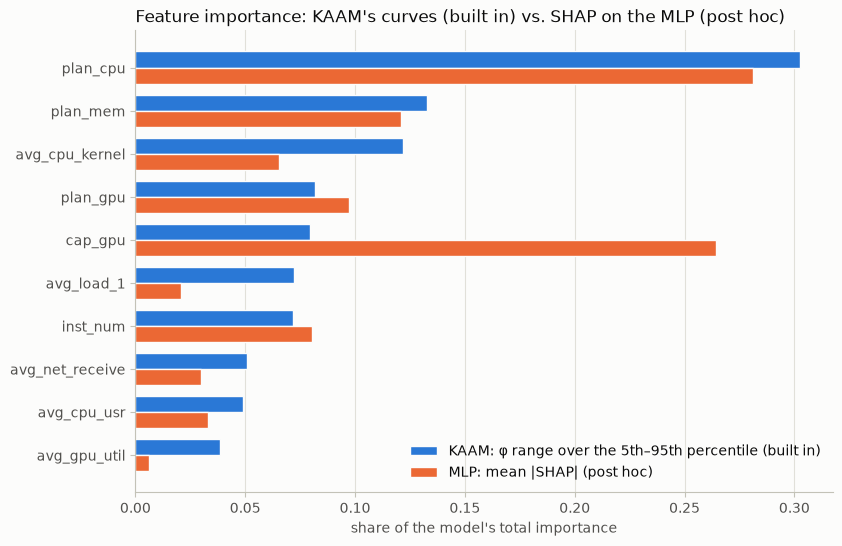

In [12]:
fig = plot_importance_comparison(rank_table)
fig.axes[0].set_title("Feature importance: KAAM's curves (built in) vs. SHAP on the MLP (post hoc)", loc="left")
plt.show()

**Is the answer an artifact of how importance was measured?** The cell below re-runs the rank correlation with three alternative definitions. None of them replaces the headline number; they show whether it is fragile.
- **KAAM's exact SHAP importance**, mean |centered $\varphi_i$| over the test tasks. This is exactly what SHAP computes for KAAM, so it is the most like-for-like comparison with the MLP's mean |SHAP|.
- **KAAM's curve range over the test split's 5th–95th percentiles** instead of the training split's.
- **Logistic regression's implied importance**: the size of its straight-line effect over the same 5th–95th percentile window, shown for the three-way contrast.

In [13]:
from scipy.stats import spearmanr

alternatives = {
    "KAAM exact SHAP (mean |centered phi| on test)": shap_importance(kaam_exact),
    "KAAM curve range, test-split p5-p95": kaam_curve_range_importance(kaam, X_test, kaam_result.feature_ranges),
    "LR |effect| over train p5-p95": lr_coefs.abs() * window,
}
rows = []
for name, imp in alternatives.items():
    r_mlp, p_mlp = spearmanr(imp, shap_imp)
    r_kaam, p_kaam = spearmanr(imp, kaam_imp)
    rows.append({"importance measure": name, "rho vs MLP SHAP": r_mlp, "p (vs MLP SHAP)": p_mlp,
                 "rho vs KAAM curve range": r_kaam, "p (vs KAAM range)": p_kaam})
print(pd.DataFrame(rows).set_index("importance measure").round(3).to_string())

                                               rho vs MLP SHAP  p (vs MLP SHAP)  rho vs KAAM curve range  p (vs KAAM range)
importance measure                                                                                                         
KAAM exact SHAP (mean |centered phi| on test)            0.758            0.011                    0.842              0.002
KAAM curve range, test-split p5-p95                      0.745            0.013                    0.988              0.000
LR |effect| over train p5-p95                            0.927            0.000                    0.939              0.000


### Shape, not just rank

A rank only says *how much* a feature matters. The plots below show *how*, for the two features the rankings agree on most and the two they disagree on most.
- On the left is the MLP's SHAP dependence plot: one dot per test task, and its vertical spread at a given x is interaction with other features.
- On the right is KAAM's $\varphi_i$, centered on the same 100 background tasks, so both panels are in log-odds relative to the average task. The x- and y-axes are shared within each row.

strongest agreement: ['plan_cpu', 'plan_gpu'] | strongest disagreement: ['cap_gpu', 'avg_cpu_kernel']


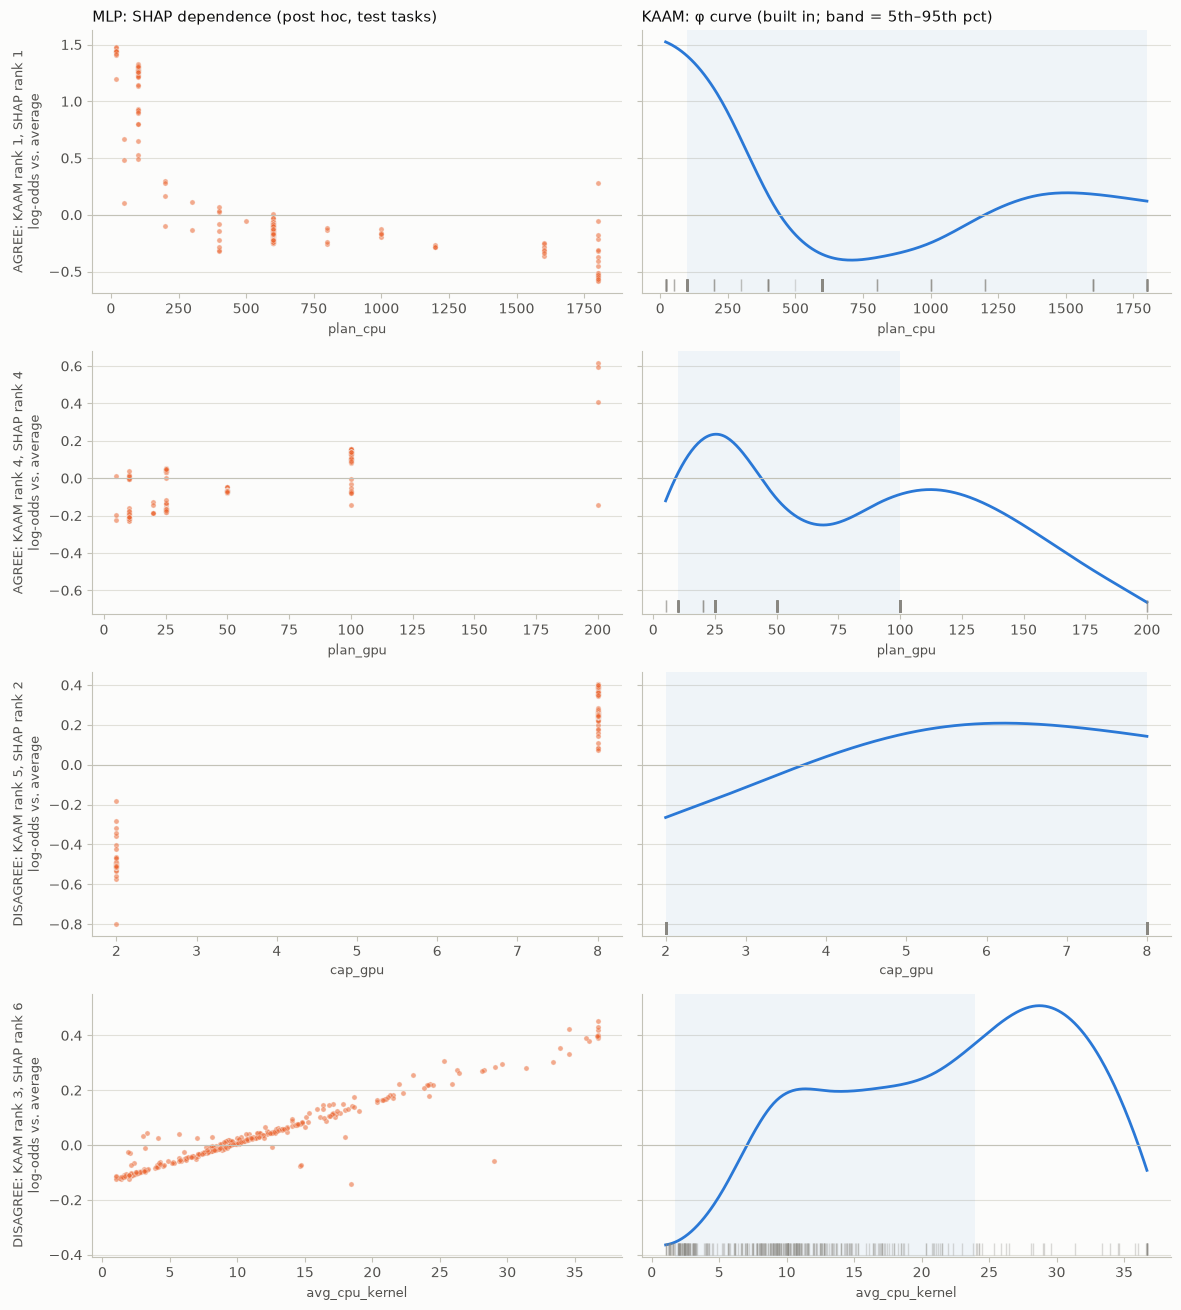

In [14]:
agree, disagree = agreement_extremes(rank_table, k=2)
labels = []
for name in agree + disagree:
    kind = "AGREE" if name in agree else "DISAGREE"
    labels.append(f"{kind}: KAAM rank {rank_table.loc[name, 'KAAM curve range rank']}, "
                  f"SHAP rank {rank_table.loc[name, 'MLP mean |SHAP| rank']}")
print("strongest agreement:", agree, "| strongest disagreement:", disagree)
fig = plot_dependence_pairs(agree + disagree, labels, X_test, mlp_shap, kaam, background, kaam_result.feature_ranges, X_train)
plt.show()

### Why the disagreements happen: correlated features

The next cell checks one hypothesis: the two models see the same signal but split the credit differently among features that carry overlapping information. Correlations come from the training split.

In [15]:
telemetry = ["avg_cpu_usr", "avg_gpu_util", "avg_cpu_kernel", "avg_load_1", "avg_net_receive"]
print("Spearman correlation of cap_gpu with each node-telemetry feature (training split):")
print(X_train[telemetry].corrwith(X_train["cap_gpu"], method="spearman").round(2).to_string())
by_pool = (X_train.assign(failed=y_train).groupby("cap_gpu")
           .agg(tasks=("failed", "size"), failure_rate=("failed", "mean"),
                median_kernel_cpu=("avg_cpu_kernel", "median"), median_load_1=("avg_load_1", "median")))
print("\nBy node pool (training split):")
print(by_pool.round(3).to_string())


def gap(values, high, low, name):
    return values.loc[high, name].mean() - values.loc[low, name].mean()


pool_8, pool_2 = X_test["cap_gpu"] == 8, X_test["cap_gpu"] == 2
kernel_hi, kernel_lo = X_test["avg_cpu_kernel"].between(9, 13), X_test["avg_cpu_kernel"] <= 3
split = pd.DataFrame({
    "MLP (SHAP)": [gap(mlp_shap, pool_8, pool_2, "cap_gpu"), gap(mlp_shap, kernel_hi, kernel_lo, "avg_cpu_kernel")],
    "KAAM (exact)": [gap(kaam_exact, pool_8, pool_2, "cap_gpu"), gap(kaam_exact, kernel_hi, kernel_lo, "avg_cpu_kernel")],
}, index=["cap_gpu: 8 vs 2 GPUs", "avg_cpu_kernel: 9-13% vs <=3%"])
split.loc["sum"] = split.sum()
print("\nHow each model splits the node-pool effect (test tasks, log-odds):")
print(split.round(2).to_string())

g25 = X_train[X_train["plan_gpu"] == 25]
print(f"\nplan_gpu = 25 on the training split: {len(g25)} tasks, {y_train.loc[g25.index].mean():.1%} failed; "
      f"{(g25['plan_cpu'] <= 100).mean():.0%} also request <= 1 CPU core, {(g25['cap_gpu'] == 8).mean():.0%} run on 8-GPU nodes")

Spearman correlation of cap_gpu with each node-telemetry feature (training split):
avg_cpu_usr        0.66
avg_gpu_util       0.75
avg_cpu_kernel     0.72
avg_load_1         0.70
avg_net_receive    0.66

By node pool (training split):
         tasks  failure_rate  median_kernel_cpu  median_load_1
cap_gpu                                                       
2.0        494         0.130              2.757         17.413
8.0       1122         0.346             11.017         82.230

How each model splits the node-pool effect (test tasks, log-odds):
                               MLP (SHAP)  KAAM (exact)
cap_gpu: 8 vs 2 GPUs                 0.77          0.41
avg_cpu_kernel: 9-13% vs <=3%        0.12          0.53
sum                                  0.89          0.94

plan_gpu = 25 on the training split: 457 tasks, 45.7% failed; 44% also request <= 1 CPU core, 81% run on 8-GPU nodes


**The finding: substantial agreement, with a specific and explainable exception.**

**Overall, the rankings agree.** KAAM's intrinsic importance and the MLP's SHAP importance have a Spearman rank correlation of **ρ = 0.78 (p = 0.0075)** across the ten features.
- The agreement doesn't depend on how importance is measured: ρ is 0.758 when KAAM's importance is taken as its own exact SHAP values, and 0.745 when its curve range is measured over the test split's percentile window.
- Both methods put the same feature on top by a wide margin: `plan_cpu`, with 30% of KAAM's total importance and 28% of the MLP's.
- Both put `avg_gpu_util` last.

A model built to be interpretable and a model explained after the fact point at the same main driver.

**Where they agree on rank, the shapes mostly agree too, but not everywhere.**
- **`plan_cpu`:** both models say small CPU requests (≤ 1 core) carry the most risk, about +1.2 to +1.5 log-odds, falling steeply by 4–6 cores. They part only above ~10 cores, where data are thin: KAAM drifts up slightly and the MLP down.
- **`plan_gpu`:** the ranks agree (4th and 4th) but the shapes don't.
  - KAAM says 25%-GPU requests are riskier (+0.23) and 200% requests safer (−0.66). The MLP's SHAP puts 25 near zero (−0.08) and 200 at +0.37.
  - Only 29 training tasks request 200%, and 4 test tasks do, so neither model's end of that curve is well supported.
  - At 25, the MLP hands the credit to correlated features: 44% of those tasks also request ≤ 1 CPU core, and 81% run on 8-GPU nodes.

**Where they disagree, it is about splitting credit between correlated features.**
- The MLP ranks `cap_gpu` 2nd (26% of its importance); KAAM ranks it 5th (8%). KAAM ranks node telemetry higher instead: `avg_cpu_kernel` 3rd vs 6th, and `avg_load_1` 6th vs 9th.
- These features are not independent. On the training split, `cap_gpu` has a Spearman correlation of 0.66–0.75 with every telemetry feature. 8-GPU nodes run a median 11.0% kernel CPU against 2.8% on 2-GPU nodes, and fail at 35% against 13%.
- Both models find about the same total node-pool effect, then split it in opposite proportions:
  - the MLP puts +0.77 log-odds on `cap_gpu` (8 vs 2 GPUs) and only +0.12 on kernel CPU (9–13% vs ≤ 3%), a total of 0.89;
  - KAAM puts +0.41 on `cap_gpu` and +0.53 on kernel CPU, a total of 0.94.
- That is why KAAM's kernel-CPU curve rises steeply between about 2% and 10%, right across the gap between the two pools' typical values, while the MLP's SHAP for kernel CPU is a gentle straight line.

Logistic regression makes the same choice as the MLP: most of the node-pool effect goes on `cap_gpu`. That is why its straight-line importance tracks the MLP's SHAP ranking even more closely (ρ = 0.93) than KAAM's does. Two models agreeing with each other doesn't show that either one's attribution is right.

**What this means for the paper.**
- The interpretability half of the claim holds where it matters most. KAAM's built-in explanation substantially agrees with an independent post-hoc explanation of an unconstrained model, both in the overall ranking and in the top driver's shape.
- The limitation is real and deserves a sentence. When features are strongly correlated, a per-feature explanation is not unique. KAAM's curves are exact for KAAM, but "the effect of kernel CPU" and "the effect of node hardware" are partly the same effect, and KAAM, SHAP and logistic regression each split it differently.
- An SRE should therefore read KAAM's node-telemetry curves together with `cap_gpu`, as a group describing the node pool, not as independent causes.

## Summary

| Question | Answer |
|---|---|
| Does KAAM reproduce Phase 3? | Yes, exactly: restored epoch 167, val BCE 0.4868, test AUC 0.7169. The refactored training loop is bit-identical. |
| Is the MLP comparison fair on capacity? | Yes: 149 parameters vs KAAM's 151 (−1.3%), chosen from candidates that are all within ±20%. |
| Does KAAM rank tasks as well as the black box? | Within noise. Test AUC is 0.730 for the MLP, 0.717 for KAAM and 0.705 for LR, and all three paired 95% intervals include zero. |
| Is KAAM as well calibrated? | Yes: Brier 0.165 vs the MLP's 0.163. LR is 0.179. |
| Does the MLP win on raw accuracy? | Nominally, yes. At 0.5 its accuracy is 0.804 vs KAAM's 0.787, and its F1 0.541 vs 0.513. At validation-tuned thresholds no model dominates. |
| Does KAAM's built-in explanation agree with SHAP? | Substantially: Spearman ρ = 0.78 (p = 0.0075). The top driver, `plan_cpu`, agrees in both rank and shape. |
| Where does it disagree? | On how to split credit within one correlated group: node hardware (`cap_gpu`) vs node telemetry (kernel CPU, load). Both models find about the same total node-pool effect (0.89 vs 0.94 log-odds) but divide it in opposite proportions. |

**The honest takeaway for the paper.** On this benchmark, KANVAS's interpretability comes at no measurable cost in ranking or calibration relative to a same-size black box, and its built-in explanation agrees with an independent post-hoc one where it matters most. The caveat is that per-feature attributions, KAAM's included, are not unique when features are strongly correlated, so correlated feature groups should be read together.

**Next:**
- a larger sample, since 347 test tasks can't resolve AUC differences of 0.01–0.02;
- checking how stable KAAM's split of credit between `cap_gpu` and the telemetry features is across random seeds;
- testing whether dropping redundant telemetry features makes the curves easier to read without costing AUC.